VGG NET
Lab Record Program 3

In [1]:
import numpy as np
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.applications.vgg16 import VGG16
from keras.models import Sequential
from keras.layers import InputLayer, Dense, Flatten, Dropout,GlobalAveragePooling2D
from keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
#Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [3]:
#To Correctly input the data into the model
print(x_train.shape)  
print(y_train.shape)  
print(x_test.shape)  
print(y_test.shape)  

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


In [4]:
#NOrmalize the images to the range [0, 1]
x_train =  x_train / 255.0
x_test = x_test / 255.0

In [5]:
#One-hot encode the labels(CIFAR-10 has 10 classes)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [6]:
#Load VGG16 model pre-trained on ImageNet , without the top paeyrs (fully connected layers)
base_model = VGG16(weights='imagenet', include_top=False)  

In [7]:
#Freeze the layer of VGG16
for layer in base_model.layers:
    layer.trainable = False

In [8]:
#Alternate method , Freeze early layers, fine tune last block
#for layer in base_model.layers[:-4]:
#    layer.trainable = False

In [9]:
#build the model
model = Sequential()

#Define the input shape
model.add(InputLayer(input_shape=(32, 32, 3)))  #Added this line for new image data

#Add THE vgg16 base model
model.add(base_model)

#Flatten . pool the output from VGG16s convolutional layers
#model.add(Flatten()) use when dataest is large an. Preserve spatial information
model.add(GlobalAveragePooling2D())  #Global Average Pooling to reduce dimensions

#Add a fully connected layer with 256 units and ReLU activation
model.add(Dense(256,activation='relu'))

#Add Dropout for regularization
model.add(Dropout(0.50))

#Add output layer with 10 units (for 10 classes ) and softmax activation
model.add(Dense(10,activation='softmax'))

#compile the model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#print model summary
model.summary()

c:\Users\user\Desktop\MCA AI DS 2027\S2\Deep Learning\Lab\tfenv\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
#data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

In [11]:
#Fit the model using data augmentation
batch_size = 64
epochs = 3
train_generator = datagen.flow(x_train, y_train, batch_size=batch_size)

In [12]:
print(y_train.shape)

(50000, 10)


In [14]:
#train model
history = model.fit(train_generator, 
                    steps_per_epoch=x_train.shape[0] // batch_size,
                    epochs=epochs,
                    validation_data=(x_test, y_test)
                   )

Epoch 1/3
781/781 ━━━━━━━━━━━━━━━━━━━━ 178s 228ms/step - accuracy: 0.4121 - loss: 1.6718 - val_accuracy: 0.4924 - val_loss: 1.4939
Epoch 2/3
  1/781 ━━━━━━━━━━━━━━━━━━━━ 2:11 168ms/step - accuracy: 0.4062 - loss: 1.5956

c:\Users\user\Desktop\MCA AI DS 2027\S2\Deep Learning\Lab\tfenv\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


781/781 ━━━━━━━━━━━━━━━━━━━━ 30s 38ms/step - accuracy: 0.4062 - loss: 1.5956 - val_accuracy: 0.4924 - val_loss: 1.4936
Epoch 3/3
781/781 ━━━━━━━━━━━━━━━━━━━━ 176s 225ms/step - accuracy: 0.4496 - loss: 1.5748 - val_accuracy: 0.5119 - val_loss: 1.4221


In [15]:
#Evaluate The Model
test_loss,test_acc = model.evaluate(x_test,y_test,verbose=2)
print(f'Test Accuracy:{test_acc}')

313/313 - 33s - 106ms/step - accuracy: 0.5119 - loss: 1.4221
Test Accuracy:0.511900007724762


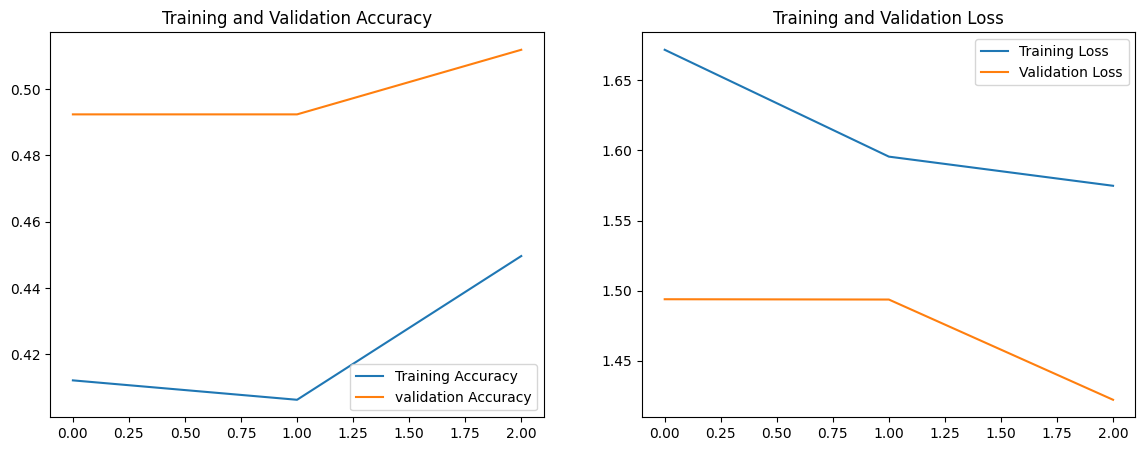

In [ ]:
#plot Training and validation accuracy and loss
import matplotlib.pyplot as plt
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='validation Accuracy')
plt.legend(loc='lower right')
plt.title("Training and Validation Accuracy")

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.savefig('./VGG16.png')
plt.show()
